# 02 — Preprocessing Pipeline 

**Project:** Fake News Detection using Deep Learning (BCA Major Project)




**No model training happens here.** The only goal of this notebook is a clean, reproducible,
staged dataset


In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path.cwd().parent))

from config.settings import REPORT_FIGURES_DIR
from preprocessing import pipeline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 100)
REPORT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)


## Stage 1 — Combine (`01_combined_raw.csv`)

 tag `Fake.csv` as label `0`, `True.csv` as label `1`, and
concatenate them into one DataFrame.



In [2]:
stage1_df, stage1_stats = pipeline.run_stage1()
stage1_stats_df = pd.DataFrame([r.__dict__ for r in stage1_stats])
stage1_stats_df


2026-07-19 18:03:45,093 | INFO | preprocessing.pipeline | Stage 1 complete: 44898 rows -> D:\sem6\MajorProject\fake-news-detection\dataset\processed\01_combined_raw.csv


,stage,step,rows_before,rows_after,reason,columns_before,columns_after
0,stage1_combine,combine_fake_and_true,44898,44898,Concatenated Fake.csv (label=0) and True.csv (label=1) and added a label column; no rows removed...,4,5


In [3]:
print(f"Rows: {len(stage1_df):,}   Columns: {list(stage1_df.columns)}")
stage1_df.head(3)


Rows: 44,898   Columns: ['title', 'text', 'subject', 'date', 'label']


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution,"21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some ...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Security Council,WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon fro...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shipping restrictions,(Reuters) - Puerto Rico Governor Ricardo Rossello said on Wednesday he expected the federal gove...,politicsNews,"September 27, 2017",1


**Result:** 44,898 rows in, 44,898 rows out — confirmed no rows were removed, and the
only change was the addition of the `label` column (4 columns → 5).


## Stage 2 — Clean (`02_cleaned.csv`)

remove rows/columns that are corrupted, duplicated, empty, or
leak the label


In [4]:
stage2_df, stage2_stats = pipeline.run_stage2(stage1_df)
stage2_stats_df = pd.DataFrame([r.__dict__ for r in stage2_stats])
stage2_stats_df


2026-07-19 18:03:47,872 | INFO | preprocessing.pipeline | Stage 2 complete: 38638 rows -> D:\sem6\MajorProject\fake-news-detection\dataset\processed\02_cleaned.csv


,stage,step,rows_before,rows_after,reason,columns_before,columns_after
0,stage2_clean,remove_corrupted_rows,44898,44888,Rows with a non-standard `date` value whose title/text were manually confirmed to contain no rea...,5,5
1,stage2_clean,remove_empty_articles,44888,44257,Rows where the `text` field is empty or whitespace-only,5,5
2,stage2_clean,deduplicate_articles,44257,38638,"Duplicate `text` values, keeping the first occurrence - see docs/duplicate_analysis.md",5,5
3,stage2_clean,strip_reuters_prefix,38638,38638,"Removed a leading Reuters wire-service dateline from 20887 rows (text modified in place, no rows...",5,5
4,stage2_clean,drop_leakage_columns,38638,38638,Dropped `subject` and `date` columns (label leakage) - see docs/label_leakage_analysis.md,5,3


### Step 2.1 — `remove_corrupted_rows`


### Step 2.2 — `remove_empty_articles`

 631 rows (630 Fake + 1 Real, confirmed in `01_dataset_analysis.ipynb`)
have an entirely empty `text` field — a title with no body.


### Step 2.3 — `deduplicate_articles`

Keyed on `text` alone — removes
articles that are exact re-publications of another row already in the data.
 If duplicate articles land on both sides of the train/test
split later, the model appears to "generalize" to a test example it actually memorized
 during training — inflating reported accuracy without proving real learning.



### Step 2.4 — `strip_reuters_prefix`

 99.2% of Real articles open with a `"(Reuters) - "` wire-service
dateline that the Fake articles almost never have.  a
99.6%-accurate shortcut completely unrelated to truthfulness.



### Step 2.5 — `drop_leakage_columns`
`subject` alone predicts the label with 100.000% accuracy;
`date` alone predicts it with 100% precision on 6.44% of rows via a date-range rule
. Neither reflects the article's actual content.

 Any model — baseline or LSTM — given direct access to
`subject` would very likely learn to read that column alone and ignore the article text
almost entirely, since it's a far easier, perfectly-predictive shortcut.



In [5]:
stage2_df.head(3)


,title,text,label
0,Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution,"21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some ...",0
1,Trump drops Steve Bannon from National Security Council,U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security...,1
2,Puerto Rico expects U.S. to lift Jones Act shipping restrictions,Puerto Rico Governor Ricardo Rossello said on Wednesday he expected the federal government to wa...,1


## Stage 3 — NLP Preprocessing (`03_preprocessed.csv`)

 turn cleaned `title`/`text` into model-ready text. This is the
only stage where the pipeline branches into two variants, because that two techniques (stop-word removal, lemmatization) should be applied differently
depending on which model will consume the text:

- **`baseline_text`** — full cleaning, including stop-word removal and lemmatization. Feeds
  the  TF-IDF + Logistic Regression baseline.
- **`lstm_text`** — same cleaning, without stop-word removal or lemmatization. Feeds the
  LSTM.



In [6]:
stage3_df, stage3_stats = pipeline.run_stage3(stage2_df)
stage3_stats_df = pd.DataFrame([r.__dict__ for r in stage3_stats])
stage3_stats_df


2026-07-19 18:04:45,107 | INFO | preprocessing.pipeline | Stage 3 complete: 38638 rows -> D:\sem6\MajorProject\fake-news-detection\dataset\processed\03_preprocessed.csv


,stage,step,rows_before,rows_after,reason,columns_before,columns_after
0,stage3_preprocess,combine_title_and_text,38638,38638,Concatenated title + text into a single `content` field; no rows removed,3,4
1,stage3_preprocess,clean_text_baseline,38638,38638,"Baseline NLP cleaning: lowercase, HTML/URL/punctuation removal, stop-word removal, lemmatization...",4,5
2,stage3_preprocess,clean_text_lstm,38638,38638,"LSTM NLP cleaning: same as baseline but WITHOUT stop-word removal or lemmatization, to preserve ...",5,6
3,stage3_preprocess,remove_rows_emptied_by_cleaning,38638,38638,Dropped rows that became empty after NLP cleaning (e.g. an article consisting only of stop words...,6,6


### Step-by-step technique explanations



**`combine_title_and_text`**
- *Why necessary?* EDA found titles carry real signal (Fake titles average 14.7 words vs.
  Real's 10.0). Combining lets the model see both without a second input branch.
- *If skipped?* The model would only see the article body, discarding a measurable style
  difference for free.
- *Baseline vs. LSTM?* Identical — both take the same combined `content` as their starting
  point.

**Lowercasing**


**HTML removal**


**URL removal**


**Punctuation removal**


**Stop-word removal**
-TF-IDF has no concept of word order, so common words like
  `"the"`/`"is"` are close to pure noise for it.
-*If skipped (baseline)? Slightly noisier TF-IDF features, diluted by very frequent,
  low-information words.
- *Baseline vs. LSTM?* They differ. The LSTM is a sequence model that can use function
  words for grammar and — critically — negation (`"not"`, `"never"`). Removing stop words
  risks flipping the meaning the LSTM would otherwise correctly use (`"did not confirm"` →
  `"confirm"`). So this step is **on** for `baseline_text` and **off** for `lstm_text`.

**Lemmatization — the second split decision**
-  Groups inflected forms (`"running"`/`"ran"`/`"runs"`) into
  one TF-IDF feature instead of three separate, weaker ones.
- If skipped (baseline) TF-IDF sees related words as unrelated, unnecessarily splitting
  their combined evidence.
- * The LSTM's embedding layer can often learn similar representations for
  inflected forms directly from data, and NLTK's default lemmatizer needs part-of-speech
  info to be fully accurate — added complexity for a smaller benefit on the LSTM side. So this
  step is **on** for `baseline_text` and **off** for `lstm_text`, same split as stop-words.

**Whitespace normalization**
- *Why necessary?* Collapses repeated spaces/newlines (common after HTML removal) into single
  spaces.
- *If skipped?* Spurious empty tokens, slightly distorted word counts.
- *Baseline vs. LSTM?* Identical — always applied, no trade-off, always safe.




In [7]:
example = stage3_df.iloc[0]
print("TITLE:\n", example["title"], "\n")
print("CONTENT (title + text, combined, uncleaned):\n", example["content"][:300], "\n")
print("BASELINE_TEXT (stopwords + lemmatization applied):\n", example["baseline_text"][:300], "\n")
print("LSTM_TEXT (stopwords + lemmatization skipped):\n", example["lstm_text"][:300])


TITLE:
 Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 

CONTENT (title + text, combined, uncleaned):
 Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements  

BASELINE_TEXT (stopwords + lemmatization applied):
 ben stein call 9th circuit court committed coup état constitution 21st century wire say ben stein reputable professor pepperdine university also hollywood fame appearing tv show film ferris bueller day made provocative statement judge jeanine pirro show recently discussing halt imposed president tru 

LSTM_TEXT (stopwords + lemmatization skipped):
 ben stein calls out 9th circuit court committed a coup d état against the constitution 21st century wire says ben stein reputable professor from pep

**Observe the difference directly:** `baseline_text` has dropped short function words
(`"a"`, `"the"`, `"is"`) and reduced words to base forms (`"calls"` → `"call"`); `lstm_text`
keeps every word in its original inflected form and in its original order — exactly the
design decision from `docs/preprocessing_plan.md`, now visible in real output rather than
just asserted.


## Pipeline Summary

All three stages' statistics, combined into one view. This is also saved as
`report/tables/preprocessing_pipeline_stats.csv` (and individually as `stage1_stats.csv`,
`stage2_stats.csv`, `stage3_stats.csv`), all under `report/tables/`.


In [8]:
all_stats_df = pd.concat(
    [stage1_stats_df, stage2_stats_df, stage3_stats_df], ignore_index=True
)
all_stats_df


,stage,step,rows_before,rows_after,reason,columns_before,columns_after
0,stage1_combine,combine_fake_and_true,44898,44898,Concatenated Fake.csv (label=0) and True.csv (label=1) and added a label column; no rows removed...,4,5
1,stage2_clean,remove_corrupted_rows,44898,44888,Rows with a non-standard `date` value whose title/text were manually confirmed to contain no rea...,5,5
2,stage2_clean,remove_empty_articles,44888,44257,Rows where the `text` field is empty or whitespace-only,5,5
3,stage2_clean,deduplicate_articles,44257,38638,"Duplicate `text` values, keeping the first occurrence - see docs/duplicate_analysis.md",5,5
4,stage2_clean,strip_reuters_prefix,38638,38638,"Removed a leading Reuters wire-service dateline from 20887 rows (text modified in place, no rows...",5,5
5,stage2_clean,drop_leakage_columns,38638,38638,Dropped `subject` and `date` columns (label leakage) - see docs/label_leakage_analysis.md,5,3
6,stage3_preprocess,combine_title_and_text,38638,38638,Concatenated title + text into a single `content` field; no rows removed,3,4
7,stage3_preprocess,clean_text_baseline,38638,38638,"Baseline NLP cleaning: lowercase, HTML/URL/punctuation removal, stop-word removal, lemmatization...",4,5
8,stage3_preprocess,clean_text_lstm,38638,38638,"LSTM NLP cleaning: same as baseline but WITHOUT stop-word removal or lemmatization, to preserve ...",5,6
9,stage3_preprocess,remove_rows_emptied_by_cleaning,38638,38638,Dropped rows that became empty after NLP cleaning (e.g. an article consisting only of stop words...,6,6


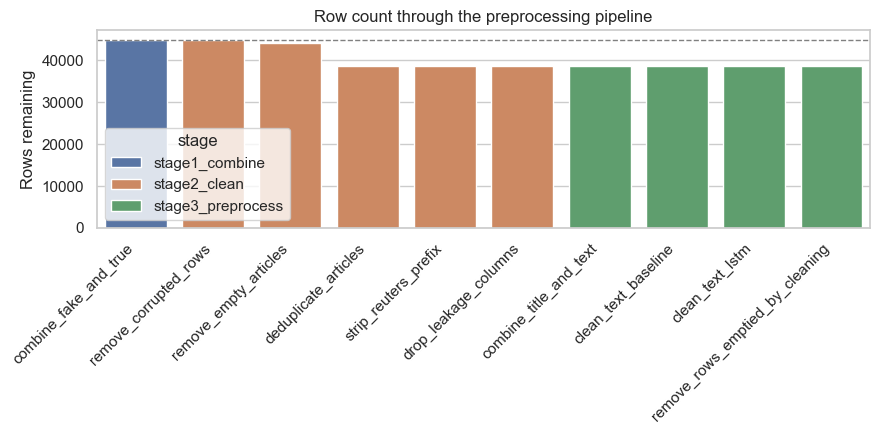

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
steps = all_stats_df["step"]
rows_after = all_stats_df["rows_after"]

sns.barplot(x=list(range(len(steps))), y=rows_after, hue=all_stats_df["stage"], dodge=False, ax=ax)
ax.set_xticks(range(len(steps)))
ax.set_xticklabels(steps, rotation=45, ha="right")
ax.set_ylabel("Rows remaining")
ax.set_xlabel("")
ax.set_title("Row count through the preprocessing pipeline")
ax.axhline(len(stage1_df), color="grey", linestyle="--", linewidth=1, label="Stage 1 start")
fig.tight_layout()
fig.savefig(REPORT_FIGURES_DIR / "preprocessing_funnel.png", dpi=150)
plt.show()
